# Text Classification Using Naive Bayes

Naives Bayes is a popular method in Natural Language Processing and Machine Learning. It basically used for classifying text documents. Text documents are classified by using Bayes Theorem. 

### Importing Libraries
•	numpy
•	matplotlib
•	pandas
•	seaborn
•	scikit-learn

In [1]:
#importing required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.feature_extraction.text import CountVectorizer

### Loading the dataset

In [2]:
#loading the test dataset
data = pd.read_csv('synthetic_text_data.csv')
X = data['text']
y = data['label']

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85 entries, 0 to 84
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    85 non-null     object
 1   label   85 non-null     object
dtypes: object(2)
memory usage: 1.5+ KB


In [4]:
data.head()

,text,label
0,Artificial intelligence is advancing in health...,Technology
1,Football fans are excited about the upcoming W...,Sports
2,New policies regarding climate change have spa...,Politics
3,The latest blockbuster movie has shattered box...,Entertainment
4,Quantum computing promises to revolutionize in...,Technology


In [5]:
data.tail()

,text,label
80,AI is enhancing customer experiences in retail...,Technology
81,Politicians are debating the pros and cons of ...,Politics
82,Television networks are trying to adapt to the...,Entertainment
83,New wearable technologies are improving health...,Technology
84,Local sports leagues are organizing tournament...,Sports


In [6]:
print("Total samples:", len(X))

Total samples: 85


### Spliting the dataset

In [7]:
#Splitting the test data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [8]:
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 68
Testing samples: 17


### Text Preprocessing

In [9]:
# here we are preprocessing the text - converting text into Numeric features
vectorizer = CountVectorizer()
X_train_vectorized = vectorizer.fit_transform(X_train)
X_test_vectorized = vectorizer.transform(X_test)

### Training the data with Naive Bayes Classifier

In [10]:
#training the Navie Bayes Classifier
model = MultinomialNB()
model.fit(X_train_vectorized, y_train)

MultinomialNB()

### Making Predictions

In [11]:
#predicting labels for the test data 
y_pred = model.predict(X_test_vectorized)

### Model Evaluation of the dataset

Accuracy: 88.23529411764706%


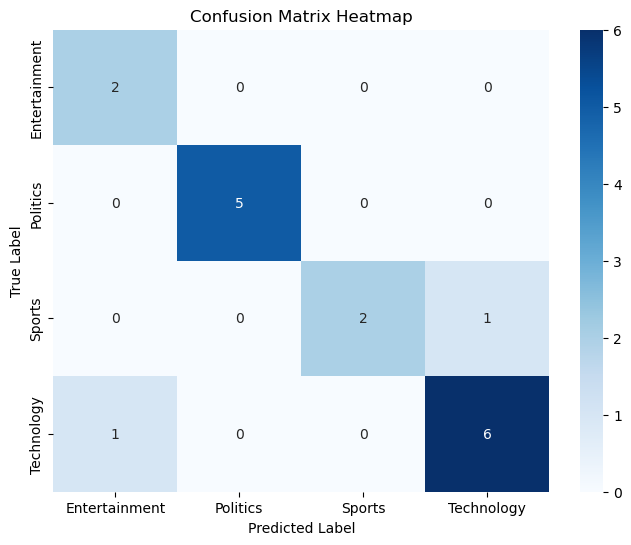

In [12]:
#evaluation of the model
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f'Accuracy: {accuracy *100}%')

class_labels = np.unique(y_test)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### Prediction of Unseen Data

In [13]:
#we are predicting some unseen data as well
user_input = ("I love artificial intelligence and machine learning")

user_input_vectorized = vectorizer.transform([user_input])
predicted_label = model.predict(user_input_vectorized)
print(f"The input text belongs to the '{predicted_label[0]}' category.")

The input text belongs to the 'Technology' category.


In [14]:
#we are predicting some unseen data as well
user_input = ("The championship football game was thrilling with an incredible match")

user_input_vectorized = vectorizer.transform([user_input])
predicted_label = model.predict(user_input_vectorized)
print(f"The input text belongs to the '{predicted_label[0]}' category.")

The input text belongs to the 'Sports' category.


In [17]:
#we are predicting some unseen data as well
user_input = ("The movie premiere was a spectacular event with celebrities and entertainment")

user_input_vectorized = vectorizer.transform([user_input])
predicted_label = model.predict(user_input_vectorized)
print(f"The input text belongs to the '{predicted_label[0]}' category.")

The input text belongs to the 'Entertainment' category.
